# eBay Laptops & Netbooks - Modeling

In this project, we aim to build a predictive model for **estimating laptop prices** using a dataset which contains cleaned information from eBay's Laptops & Netbooks category, originally obtained via web scraping, which includes product attributes such as brand, specifications, and other listing details.

The model utilizes **CatBoost** (*Categorical Boosting*), a state-of-the-art gradient boosting library [developed by Yandex][Yandex CatBoost], renowned for its efficiency in handling categorical features and its strong performance in regression, classification & ranking.

<div align="center">
<img src="../assets/logos/catboost_logo.png" height="225" width="225"/>
</div>

[Yandex Catboost]: https://yandex.com/dev/catboost/

## Links & Information

**Project Repository** - GitHub: [Laptop Price Prediction with CatBoost][Project Code]

[Project Code]: https://github.com/jxareas/laptop-price-catboost


### Importing Libraries

In this project, we will leverage several powerful libraries for efficient data manipulation, feature engineering, modeling, and hyperparameter tuning.

- **Scikit-learn**: Used for **training the model**, performing model evaluation, and splitting the dataset in train, validation & test sets.
- **CatBoost**: The **core library** for modeling, used to design a gradient boosting model to handle categorical features effectively and provide good performance in regression tasks.
- **Optuna**: Utilized for **hyperparameter tuning**, automating the process of finding the best model parameters to improve performance.
- **Feature Engine**: A library for **feature engineering** that provides various techniques for transforming and selecting features, ensuring that our model has the most relevant data.
- **Seaborn**: Used for **exploratory data analysis (EDA)** and plotting, providing intuitive and high-level visualizations to understand the dataset and its relationships.
- **SHAP**: Used for **model interpretability**, providing insights into how each feature influences the model's predictions, helping to explain the decisions made by the model & empowering **Explainable AI**.

These libraries will work together to ensure a streamlined and efficient manner for building and optimizing the predictive model.


In [127]:
# Importing libraries and setting constants

from typing import Tuple

# Libraries
import polars as pl
import seaborn as sns
import seaborn.objects as so
import catboost as cb
from feature_engine.encoding import RareLabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from textblob import TextBlob

# Constants
RANDOM_SEED = 287
DATA_SOURCE_PATH = '../data/ebay_laptops_and_netbooks_cleansed.csv'


## Data Preparation

### Loading the dataset

In [128]:
df = pl.read_csv(DATA_SOURCE_PATH)
df.describe()

statistic,brand,currency,min_price,rating,five_star_scale_rating,ratings_count,condition_label,condition_description,seller_note,processor,screen_size_inches,manufacturer_color,color,hard_drive_size,hard_drive_size_unit,ram_size,ram_size_unit,ssd_size,ssd_size_unit,gpu_type,processor_speed,processor_speed_unit,laptop_type,release_year,display_width,display_height,model,os,features,country_of_manufacturer,storage_type
str,str,str,f64,str,f64,f64,str,str,str,str,f64,str,str,f64,str,f64,str,f64,str,str,f64,str,str,f64,f64,f64,str,str,str,str,str
"""count""","""4475""","""4475""",4475.0,"""220""",220.0,220.0,"""4475""","""4475""","""1119""","""3005""",2653.0,"""4475""","""4475""",1115.0,"""1883""",1659.0,"""1661""",2203.0,"""2229""","""4475""",2139.0,"""4475""","""4475""",608.0,1757.0,1757.0,"""2516""","""4475""","""2040""","""4475""","""4475"""
"""null_count""","""0""","""0""",0.0,"""4255""",4255.0,4255.0,"""0""","""0""","""3356""","""1470""",1822.0,"""0""","""0""",3360.0,"""2592""",2816.0,"""2814""",2272.0,"""2246""","""0""",2336.0,"""0""","""0""",3867.0,2718.0,2718.0,"""1959""","""0""","""2435""","""0""","""0"""
"""mean""",null,null,330.473499,null,4.579545,36.613636,null,null,null,null,13.802544,null,null,228.67548,null,20.451477,null,268.47922,null,null,2.674403,null,null,2019.333882,1668.900398,962.07399,null,null,null,null,null
"""std""",null,null,393.470717,null,0.580733,178.959476,null,null,null,null,1.613322,null,null,223.964855,null,204.630743,null,225.465882,null,null,17.267134,null,null,3.113245,481.707245,307.982614,null,null,null,null,null
"""min""","""acer""","""$""",4.42,"""1_out_of_5_stars""",1.0,1.0,"""certified_refurbished""","""A brand-new, unused, unopened,…","""“""Excellent Condition Touch Sc…","""10th_gen_intel_core_i5""",2.0,"""black""","""beige""",0.0,"""gigabytes""",1.0,"""gigabytes""",0.0,"""gigabytes""","""amd""",1.0,"""GHz""","""laptop""",2000.0,800.0,480.0,"""100e_chromebook""","""android""",""".""","""australia""","""emmc"""
"""25%""",null,null,99.99,null,4.5,2.0,null,null,null,null,13.0,null,null,16.0,null,4.0,null,120.0,null,null,1.8,null,null,2018.0,1280.0,720.0,null,null,null,null,null
"""50%""",null,null,235.0,null,4.5,4.0,null,null,null,null,14.0,null,null,256.0,null,8.0,null,240.0,null,null,2.3,null,null,2020.0,1366.0,768.0,null,null,null,null,null
"""75%""",null,null,411.49,null,5.0,16.0,null,null,null,null,15.0,null,null,500.0,null,16.0,null,480.0,null,null,2.6,null,null,2022.0,1920.0,1080.0,null,null,null,null,null
"""max""","""zzetze""","""$""",3901.0,"""5_out_of_5_stars""",5.0,1533.0,"""very_good_refurbished""","""The item shows moderate wear a…","""“✅ Refurbished ✅ inkl. 19% MwS…","""v19""",18.4,"""teal""","""yellow""",3500.16,"""unknown""",8192.0,"""unknown""",1024.0,"""unknown""","""unknown""",800.0,"""unknown""","""unknown""",2024.0,3840.0,2400.0,"""zbook_14u_g6""","""windows""","""wifi,webcam,bt""","""unknown""","""unknown"""


## Exploratory Data Analysis


In [129]:
# TODO : Exploratory Data Analysis

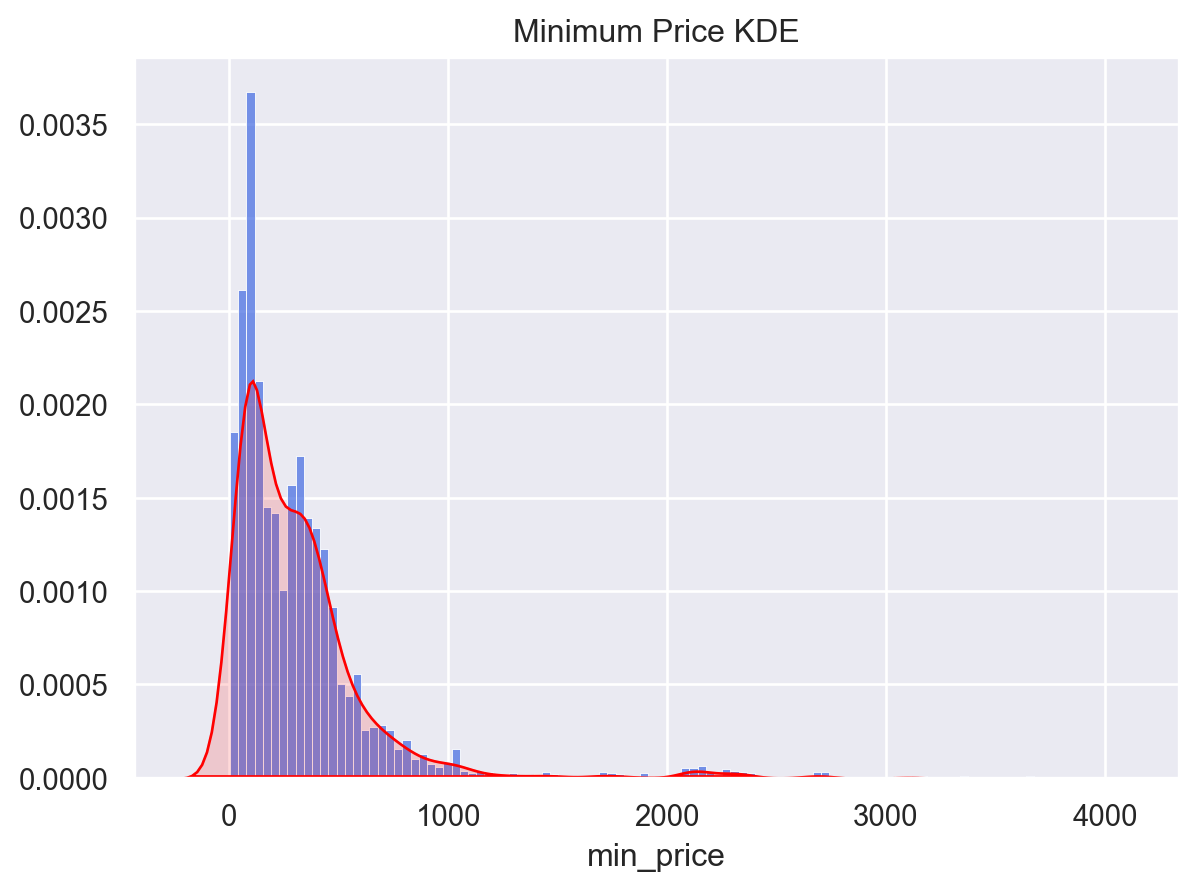

In [130]:
(
    so.Plot(df, x='min_price')
    .add(so.Bars(color='royalblue'), so.Hist('density'))
    .add(so.Area(color='red', alpha=.15), so.KDE())
    .label(title='Minimum Price KDE')
)

In [131]:
## TODO : More EDA - AutoEDA? (SweetViz, AutoViz, pandas-profiling) or manual? TBD

## Feature Engineering


### Feature Creation

#### **Sentiment Analysis** for `seller_note`

In this section, we perform sentiment analysis on the `seller_note` feature from the eBay dataset using [TextBlob][TextBlob], a simple library that helps analyze and process textual data, built upon python's [Natural Language Toolkit][NLTK]. The goal is to evaluate the sentiment expressed in the seller's notes, identifying whether the comments are **positive**, **negative**, or **neutral**.

We calculate the *polarity* and *subjectivity* of each note to understand the sentiment's intensity and whether it reflects personal opinions or objective facts. This simple analysis can help **assess the overall tone of the seller's descriptions**.

Notes:
- **Polarity** measures the sentiment's intensity, ranging from **-1** (negative) to **+1** (positive).
  A score close to **0** indicates neutral sentiment.
- **Subjectivity** measures how subjective or opinionated the text is, ranging from **0** (very objective) to **1** (very subjective). Higher subjectivity indicates that the text reflects personal opinions or feelings, while lower subjectivity suggests it is more factual.

<div align="center">
<img src="../assets/images/textblob_working.png" height="100" width="550"/>
<br>
<a href="https://www.researchgate.net/figure/Working-of-the-TextBlob-method_fig7_350191934"><i>Working of the TextBlob method</i></a>
</div>

[TextBlob]: https://github.com/sloria/TextBlob
[NLTK]: https://github.com/nltk/nltk

In [132]:
df.select(
    'seller_note'
).filter(
    pl.col('seller_note').is_not_null()
).head(n=10).to_pandas()

,seller_note
0,“Refurbished laptop in good condition”
1,“Extremely Clean. No Scratches. See Photos & D...
2,“This computer has been restored back to facto...
3,“Good Condition. These have some minor scuffs ...
4,“Fresh install of Windows 10. Good condition w...
5,“DELL Latitude Laptop Win 7 DVDRW WiFi MS.word...
6,“Very good with 4GB RAM and 128GB Storage. Ful...
7,“Factory Refurbished / A+ GRADE / SEALED IN BO...
8,“AAA PCs is a Microsoft Authorized Refurbisher...
9,“fully tested one year warranty”


In [133]:
def get_sentiment_label_by_polarity(polarity: float, threshold: float = 0.1) -> str:
    """
    Assigns a sentiment label based on polarity.

    Parameters:
    -----------
    polarity : float
        The polarity score (-1 to 1).

    threshold : float, optional, default=0.1
        The threshold for determining the label: 'positive', 'negative', or 'neutral'.

    Returns:
    --------
    str
        A sentiment label ('positive', 'negative', or 'neutral').
    """
    if polarity > threshold:
        return "positive"
    elif polarity < -threshold:
        return "negative"
    return "neutral"


def get_sentiment_features(text: str, threshold: float = 0.1) -> Tuple[float, float, str]:
    """
    Analyzes sentiment of the given text using TextBlob.

    Parameters:
    -----------
    text : str
        The text to analyze (e.g., seller note).

    threshold : float, optional, default=0.1
        The threshold for determining sentiment labels.

    Returns:
    --------
    Tuple[float, float, str]
        - polarity (float): The polarity score (-1 to 1).
        - subjectivity (float): The subjectivity score (0 to 1).
        - sentiment_label (str): 'positive', 'negative', or 'neutral'.
    """
    blob = TextBlob(text)

    polarity = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity
    sentiment_label = get_sentiment_label_by_polarity(polarity, threshold)

    return polarity, subjectivity, sentiment_label


In [134]:
def get_polarity(text: str, threshold: float = 0.1) -> float:
    """
    Extracts the polarity score from the sentiment of the given text.

    Parameters:
    -----------
    text : str
        The text to analyze for sentiment polarity.

    threshold : float, optional, default=0.1
        The threshold for determining sentiment polarity, passed to
        the `get_sentiment_features` function.

    Returns:
    --------
    float
        The polarity score, ranging from -1 (negative) to 1 (positive).
    """
    polarity, _, _ = get_sentiment_features(text, threshold)
    return polarity


def get_subjectivity(text: str, threshold: float = 0.1) -> float:
    """
    Extracts the subjectivity score from the sentiment of the given text.

    Parameters:
    -----------
    text : str
        The text to analyze for sentiment subjectivity.

    threshold : float, optional, default=0.1
        The threshold for determining sentiment polarity, passed to
        the `get_sentiment_features` function.

    Returns:
    --------
    float
        The subjectivity score, ranging from 0 (objective) to 1 (subjective).
    """
    _, subjectivity, _ = get_sentiment_features(text, threshold)
    return subjectivity


def get_sentiment_label(text: str, threshold: float = 0.1) -> str:
    """
    Extracts the sentiment label ('positive', 'negative', or 'neutral')
    based on the polarity of the given text.

    Parameters:
    -----------
    text : str
        The text to analyze for sentiment and label.

    threshold : float, optional, default=0.1
        The threshold for determining sentiment polarity, passed to
        the `get_sentiment_features` function.

    Returns:
    --------
    str
        The sentiment label: 'positive', 'negative', or 'neutral'.
    """
    _, _, sentiment_label = get_sentiment_features(text, threshold)
    return sentiment_label


In [135]:
df = df.with_columns(
    # Polarity
    pl.col('seller_note')
    .map_elements(function=get_polarity, return_dtype=pl.Float64)
    .alias('seller_note_polarity'),
    # Subjectivity
    pl.col('seller_note')
    .map_elements(function=get_subjectivity, return_dtype=pl.Float64)
    .alias('seller_note_subjectivity'),
    # Sentiment Label
    pl.col('seller_note')
    .map_elements(function=get_sentiment_label, return_dtype=pl.Utf8)
    .alias('seller_note_sentiment_label'),
)

Visualizing the new features for the seller notes:

In [136]:
df.select(
    'seller_note', 'seller_note_polarity', 'seller_note_subjectivity', 'seller_note_sentiment_label'
).filter(
    pl.col('seller_note').is_not_null()
).with_columns(
    pl.col('seller_note_polarity').round(2).alias('seller_note_polarity'),
    pl.col('seller_note_subjectivity').round(2).alias('seller_note_subjectivity'),
)

seller_note,seller_note_polarity,seller_note_subjectivity,seller_note_sentiment_label
str,f64,f64,str
"""“Refurbished laptop in good co…",0.7,0.6,"""positive"""
"""“Extremely Clean. No Scratches…",0.37,0.7,"""positive"""
"""“This computer has been restor…",0.11,0.27,"""positive"""
"""“Good Condition. These have so…",0.07,0.68,"""neutral"""
"""“Fresh install of Windows 10. …",0.35,0.5,"""positive"""
…,…,…,…
"""“Pre-owned, Battery excellent …",0.75,0.75,"""positive"""
"""“Good working and in cosmetic …",0.7,0.6,"""positive"""
"""“Base is missing one rubber fo…",-0.5,0.53,"""negative"""


#### **Visualization** - Seller Note Polarity

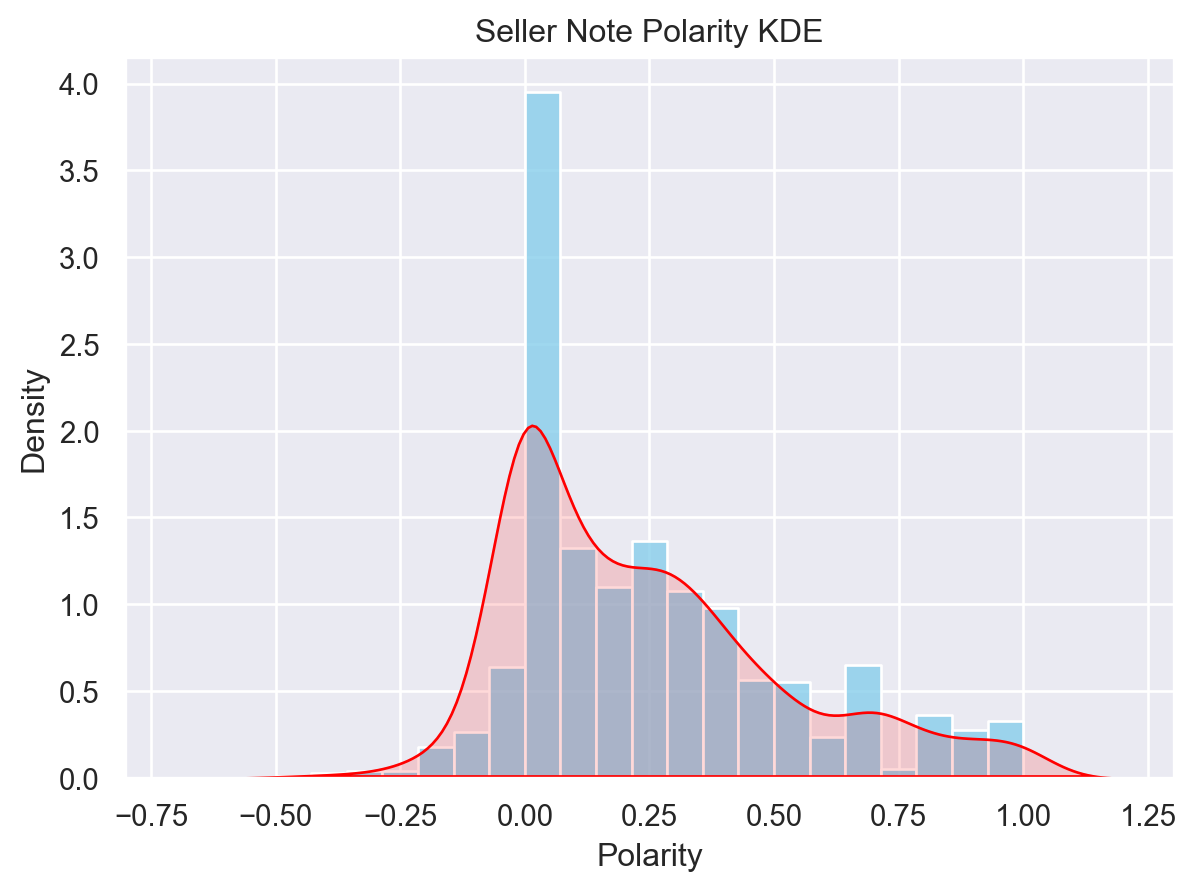

In [137]:
(
    so.Plot(df, x='seller_note_polarity')
    .add(so.Bars(color='skyblue', alpha=.8), so.Hist('density'))
    .add(so.Area(color='red', alpha=.15), so.KDE())
    .label(title='Seller Note Polarity KDE', x='Polarity', y='Density')
)

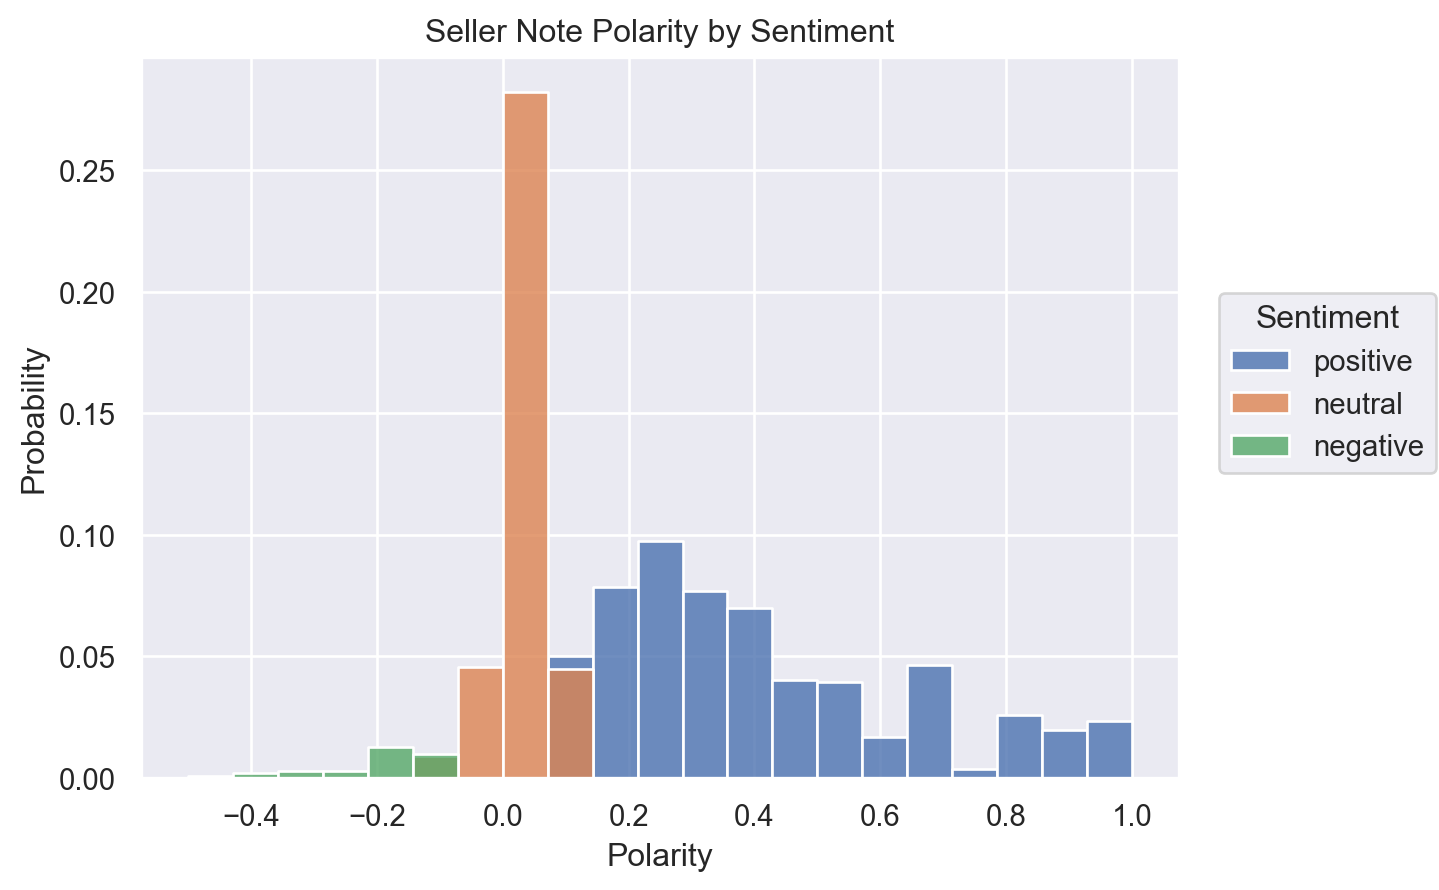

In [138]:
(
    so.Plot(df, x='seller_note_polarity', color='seller_note_sentiment_label')
    .add(so.Bars(alpha=.8), so.Hist('probability'))
    .label(title='Seller Note Polarity by Sentiment', x='Polarity', y='Probability', color='Sentiment')
)

#### **Visualization** - Seller Note Subjectivity

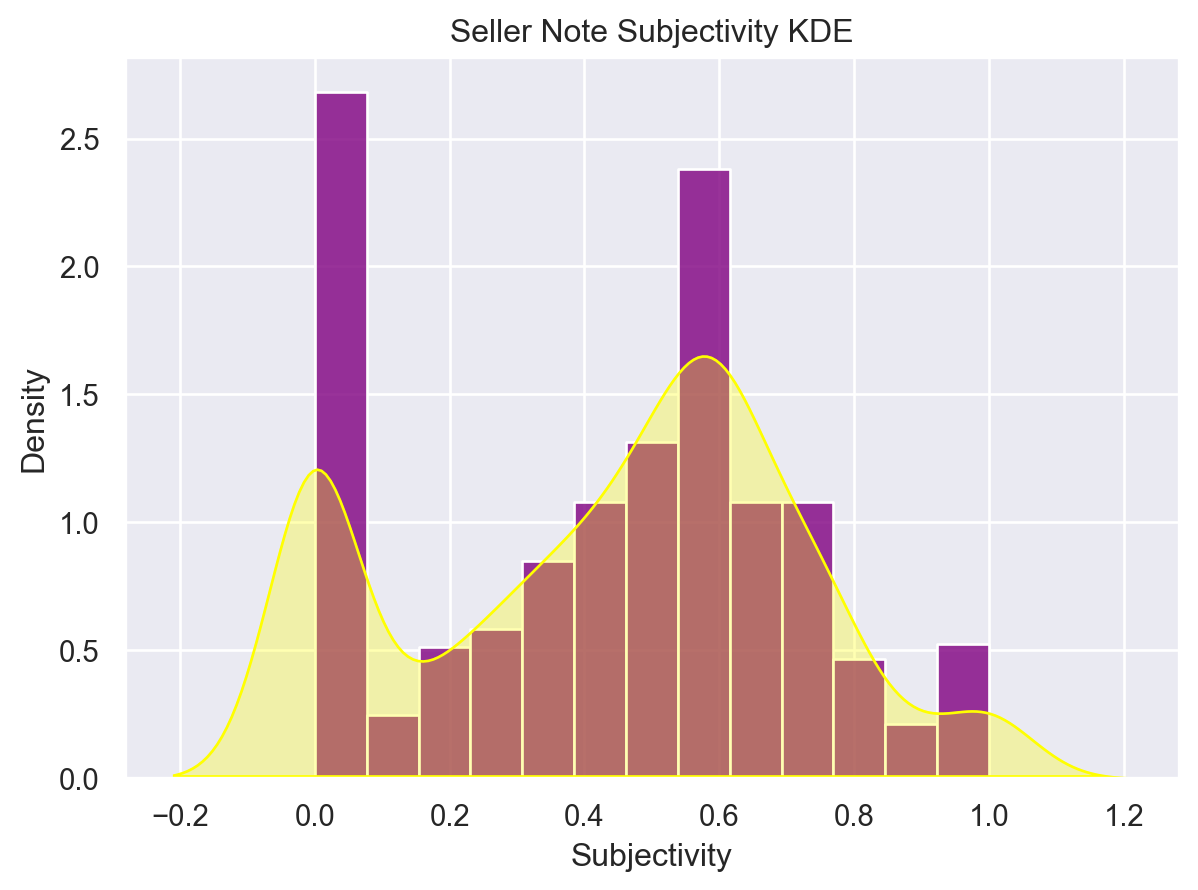

In [139]:
(
    so.Plot(df, x='seller_note_subjectivity')
    .add(so.Bars(color='purple', alpha=.8), so.Hist('density'))
    .add(so.Area(color='yellow', alpha=.3), so.KDE())
    .label(title='Seller Note Subjectivity KDE', x='Subjectivity', y='Density')
)

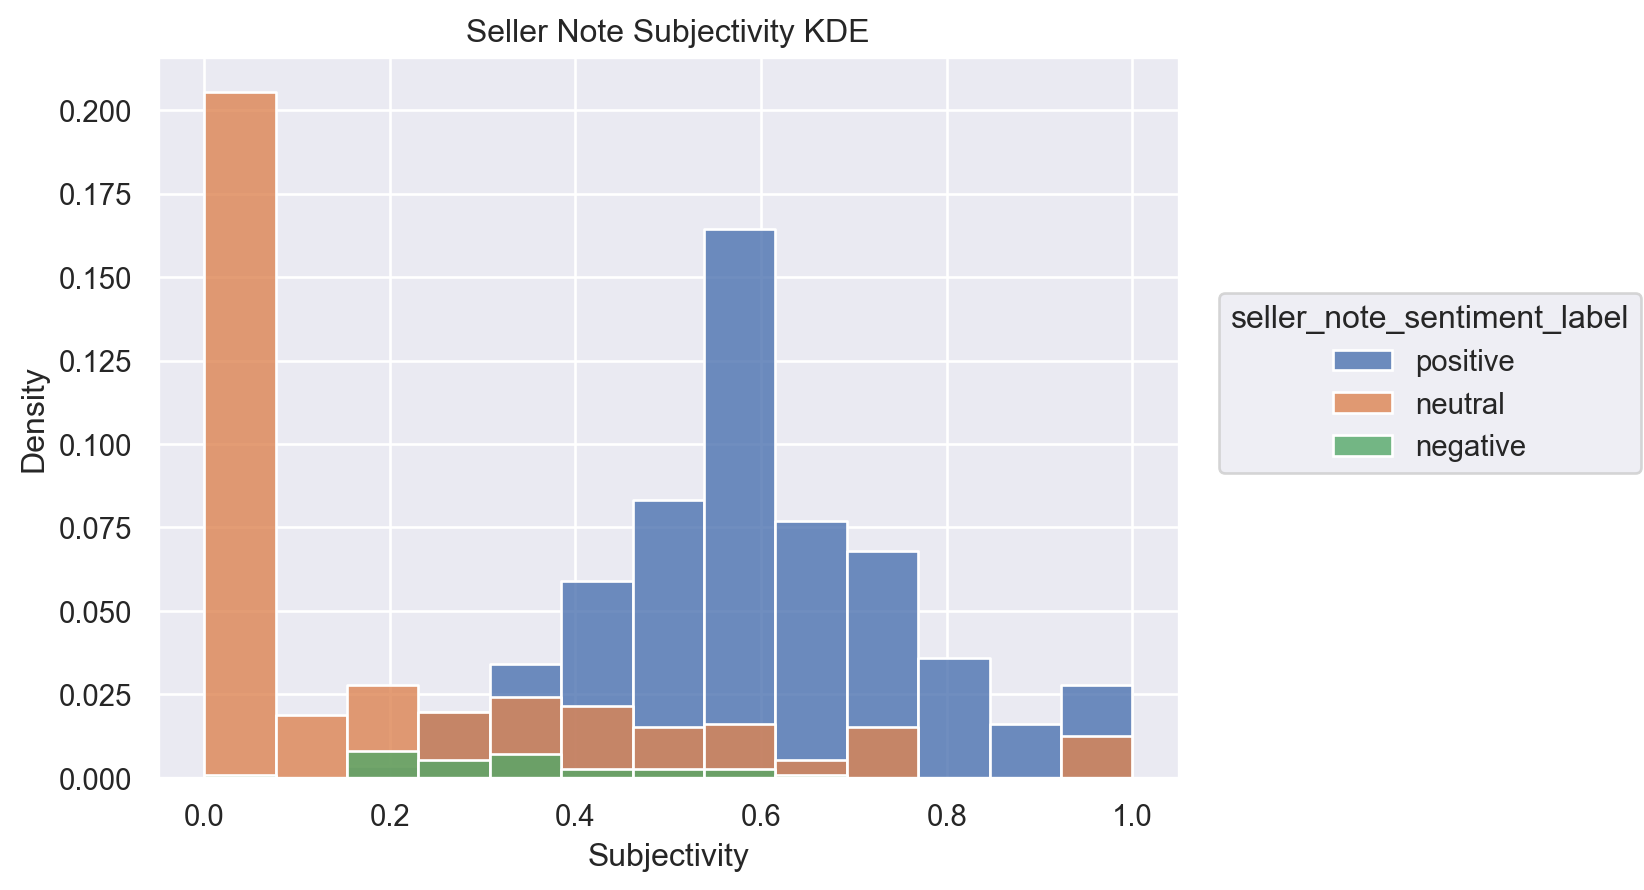

In [140]:
(
    so.Plot(df, x='seller_note_subjectivity', color='seller_note_sentiment_label')
    .add(so.Bars(alpha=.8), so.Hist('probability'))
    .label(title='Seller Note Subjectivity KDE', x='Subjectivity', y='Density')
)

#### **Visualization** - Seller Note Sentiment

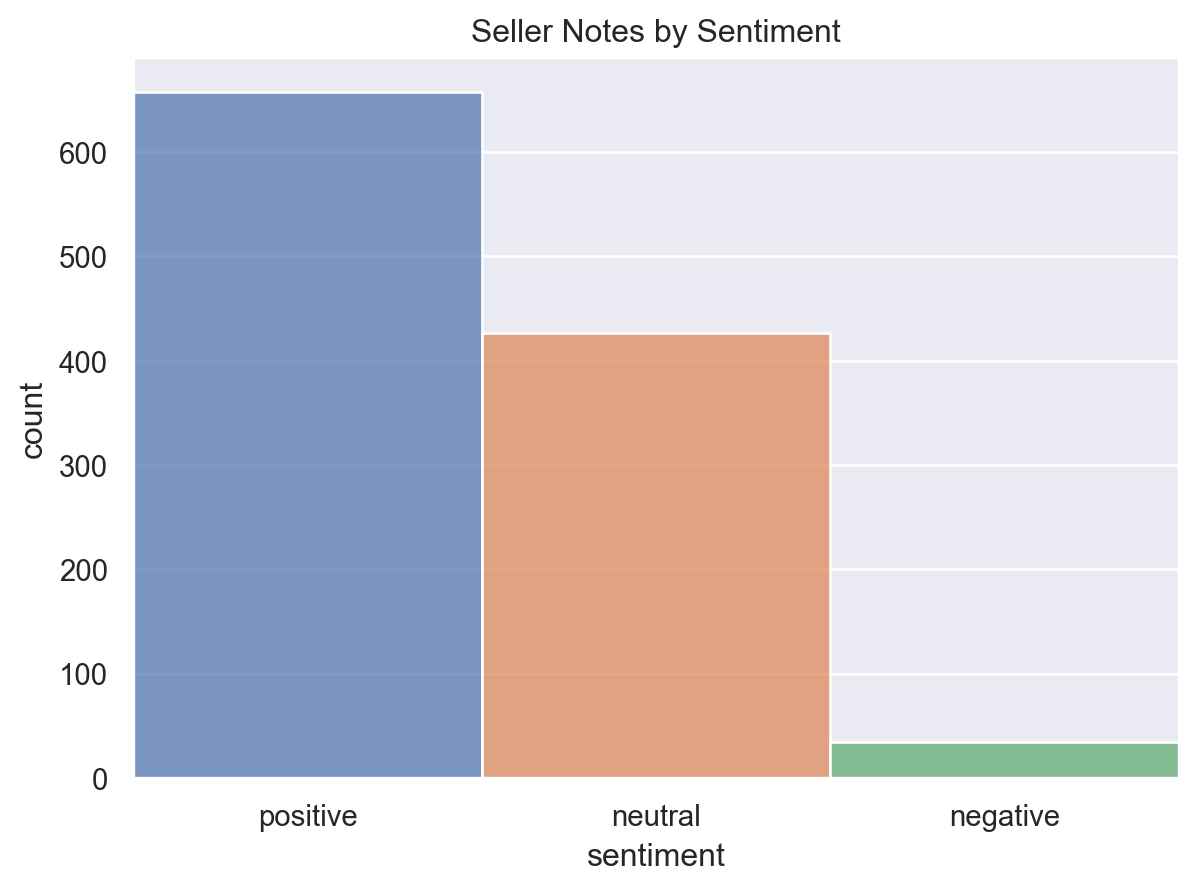

In [141]:
(
    so.Plot(df, x='seller_note_sentiment_label', color='seller_note_sentiment_label')
    .add(so.Bars(), so.Hist(), legend=False)
    .label(title='Seller Notes by Sentiment', x='sentiment', y='count')
)

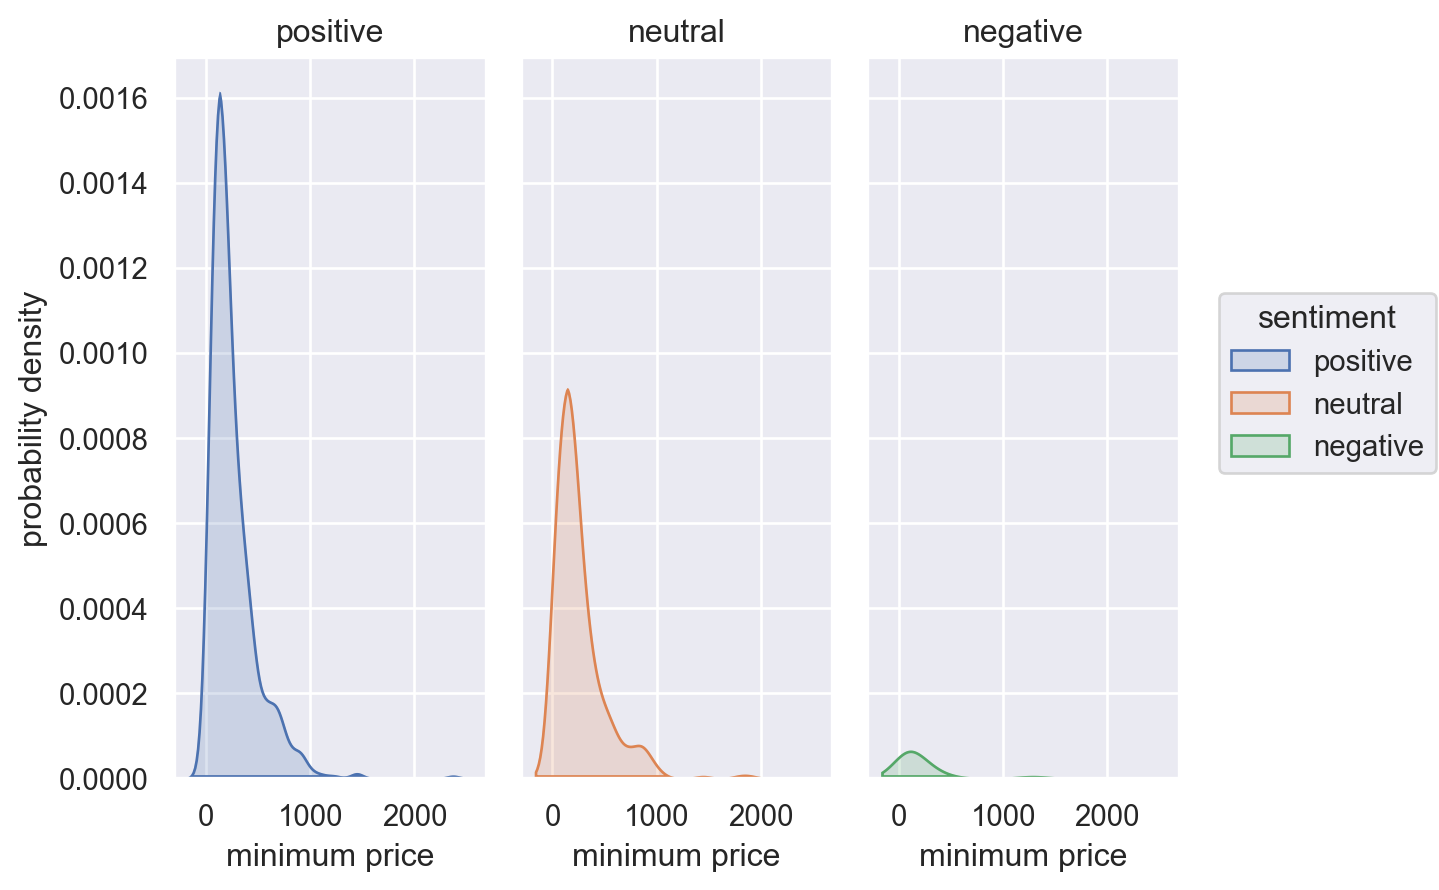

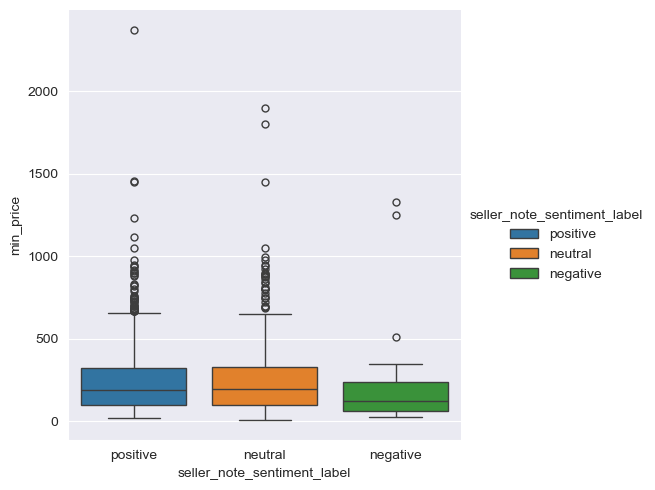

In [142]:
sns.catplot(data=df, x='seller_note_sentiment_label', kind='box', y='min_price', hue='seller_note_sentiment_label')

(
    so.Plot(df, x="min_price", color='seller_note_sentiment_label')
    .facet("seller_note_sentiment_label")
    .add(so.Area(), so.KDE())
    .label(x='minimum price', y='probability density', color='sentiment')
)

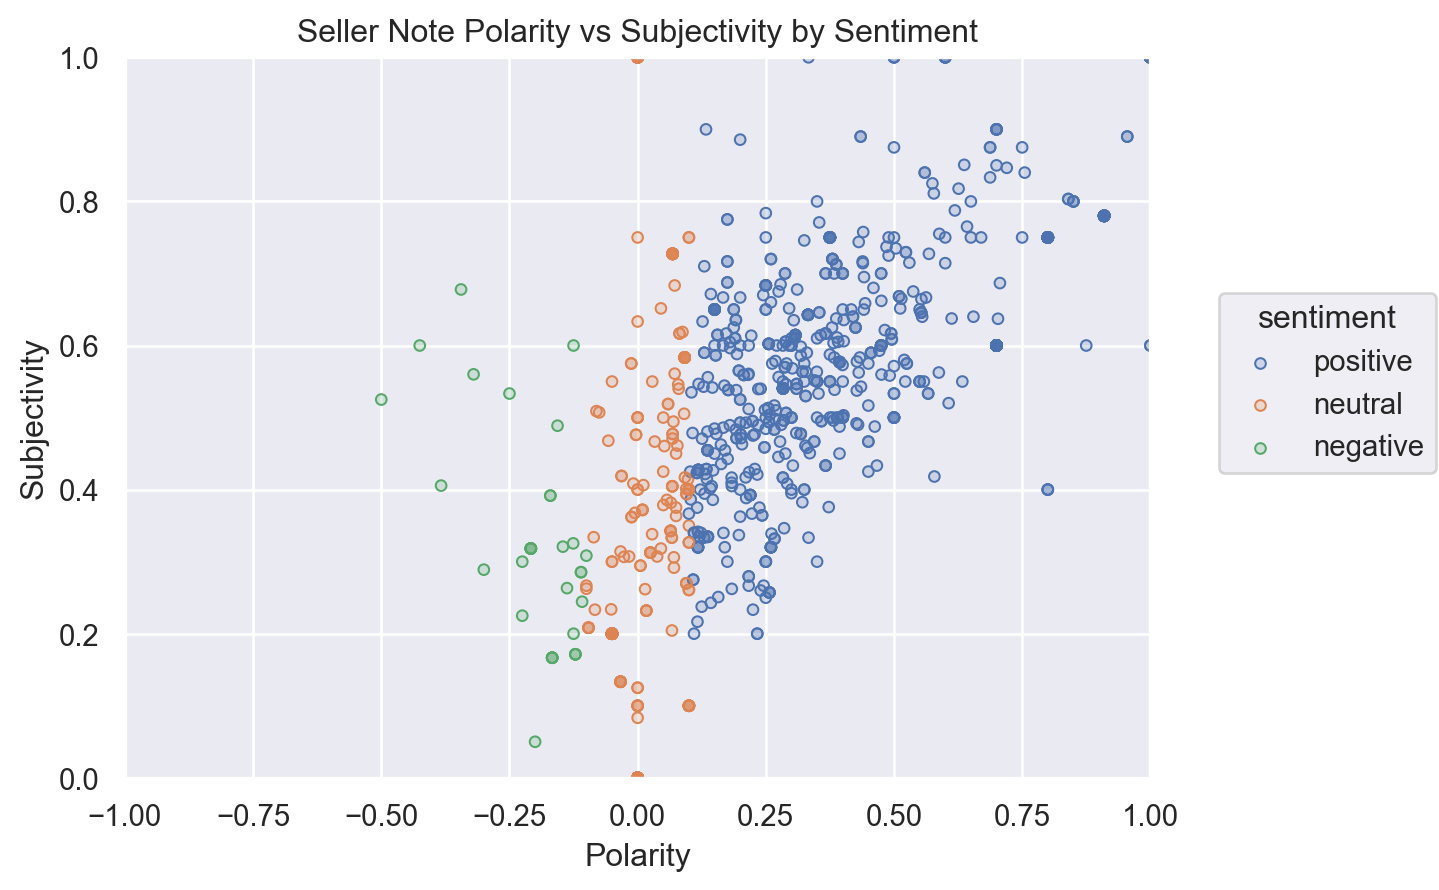

In [143]:
(
    so.Plot(df, x='seller_note_polarity', y='seller_note_subjectivity', color='seller_note_sentiment_label')
    .add(so.Dots())
    .limit(x=(-1, 1), y=(0, 1))
    .label(title='Seller Note Polarity vs Subjectivity by Sentiment', x='Polarity', y='Subjectivity', color='sentiment')
)

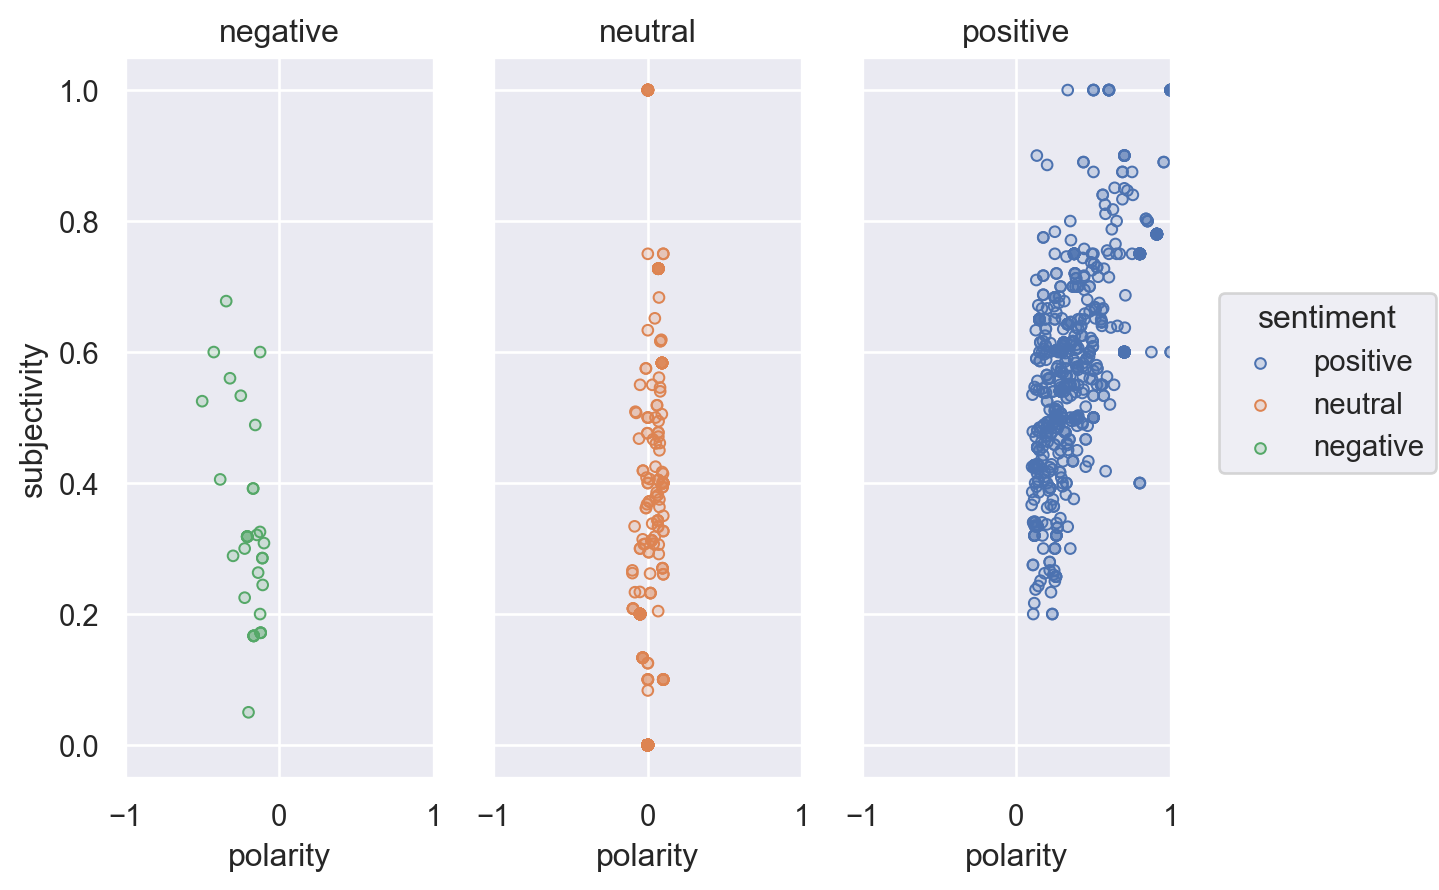

In [144]:
(
    so.Plot(df, x="seller_note_polarity", y='seller_note_subjectivity', color='seller_note_sentiment_label')
    .facet("seller_note_sentiment_label", order=['negative', 'neutral', 'positive'])
    .add(so.Dots())
    .limit(x=(-1, 1))
    .label(x='polarity', y='subjectivity', color='sentiment')
)

#### Standardizing hard drive, RAM & SSD size to their size in gigabytes

In [145]:
df.select([
    pl.col(col).unique().alias(col)
    for col in df.columns if col.endswith('_unit') and not col.startswith('processor')
])

hard_drive_size_unit,ram_size_unit,ssd_size_unit
str,str,str
"""terabytes""",null,null
null,"""gigabytes""","""unknown"""
"""unknown""","""megabytes""","""gigabytes"""
"""gigabytes""","""unknown""","""terabytes"""


In [146]:
def convert_to_gb(df_to_convert: pl.DataFrame, size_column: str, unit_column: str):
    """
    Convert size values to gigabytes based on the unit column.

    Args:
        df_to_convert (pl.DataFrame): DataFrame with size and unit columns.
        size_column (str): Column containing size values.
        unit_column (str): Column containing units (e.g., 'gigabytes', 'megabytes', 'terabytes').

    Returns:
        pl.DataFrame: DataFrame with a new column `<size_column>_in_gb` containing size in gigabytes.
    """
    return df_to_convert.with_columns(
        pl.when(df_to_convert[unit_column] == "gigabytes").then(df_to_convert[size_column])
        .when(df_to_convert[unit_column] == "megabytes").then(df_to_convert[size_column] / 1024)
        .when(df_to_convert[unit_column] == "terabytes").then(df_to_convert[size_column] * 1024)
        .otherwise(None).alias(f"{size_column}_in_gb")
    )


In [147]:
size_columns = [col for col in df.columns if col.endswith('_size')]

for size_col in size_columns:
    unit_col = f"{size_col}_unit"
    df = convert_to_gb(df, size_col, unit_col)

In [148]:
for size in size_columns:
    print(f'\nNon-null values for {size}: {df[size].drop_nulls().len()}')
    size_in_gb = f'{size}_in_gb'
    print(f'Non-null values for {size_in_gb}: {df[size_in_gb].drop_nulls().len()}')


Non-null values for hard_drive_size: 1115
Non-null values for hard_drive_size_in_gb: 1105

Non-null values for ram_size: 1659
Non-null values for ram_size_in_gb: 1656

Non-null values for ssd_size: 2203
Non-null values for ssd_size_in_gb: 2187


### Feature Selection

In [149]:
# The target variable : the minimum pricer required to purchase the item (laptop/netbook)
target_var = 'min_price'
# A polars expression for feature selection
feature_selection_expr = pl.all().exclude(target_var, 'currency', 'condition_description', 'seller_note',
                                          'seller_note_sentiment_label', 'hard_drive_size', 'hard_drive_size_unit',
                                          'ram_size', 'ram_size_unit', 'ssd_size', 'ssd_size_unit')

# Dataframe holding all feature variables
df_features = df.select(
    feature_selection_expr
)
# Series holding the target vector
series_target = df[target_var]

### Categorical Features

In [150]:
feature_names = df_features.columns
cat_feature_names = df_features.select(
    pl.col(pl.String),
).columns

print(f'{feature_names=}')

feature_names=['brand', 'rating', 'five_star_scale_rating', 'ratings_count', 'condition_label', 'processor', 'screen_size_inches', 'manufacturer_color', 'color', 'gpu_type', 'processor_speed', 'processor_speed_unit', 'laptop_type', 'release_year', 'display_width', 'display_height', 'model', 'os', 'features', 'country_of_manufacturer', 'storage_type', 'seller_note_polarity', 'seller_note_subjectivity', 'hard_drive_size_in_gb', 'ram_size_in_gb', 'ssd_size_in_gb']


### Encoding rare labels

In this project, we leverage the [**Feature-engine**][Feature-Engine] package to handle categorical variables efficiently, specifically using `RareLabelEncoder` to group infrequent categories under a common label.

Rare categories in a dataset can introduce **high cardinality**, making statistical analysis and model generalization more challenging. By setting a **minimum frequency threshold**, we ensure that only sufficiently common categories remain distinct, while rare ones are grouped into an "other" category.

This reduces noise, prevents overfitting, and enhances model interpretability without significantly losing information.

<div align="center">
<img src="../assets/logos/feature_engine.png" height="150" width="150"/>
<img src="../assets/images/rare_label_encoding.png" height="300" width="500"/>
</div>

[Feature-Engine]: https://github.com/feature-engine/feature_engine

In [151]:
# Sets the minimum count for a category to be kept separately, categories with fewer than 20 occurrences will be grouped.
MIN_COUNT_FOR_LABEL = 20
# Sets the tolerance for rare categories based on the minimum count and total number of rows in the dataset.
TOLERANCE_FOR_LABEL = MIN_COUNT_FOR_LABEL / df_features.height

encoder = RareLabelEncoder(n_categories=1, replace_with='other', tol=TOLERANCE_FOR_LABEL)
for col in cat_feature_names:
    encoder_transform = encoder.fit_transform(df_features[[col]].fill_null('unknown').to_pandas())
    df_features = df_features.with_columns(
        pl.Series(encoder_transform[col])
    )

## Machine Learning

In [152]:
# TODO : Machine Learning

### Splitting the data - Train-Validation-Test Split

<div align="center">
<img src="../assets/images/train_test_validation_split.png" height="326" width="500"/>
</div>

In [153]:
stratify_col = 'brand'

df_train, df_val_and_test, series_train, series_val_and_test = train_test_split(
    df_features,
    series_target,
    stratify=df_features[stratify_col],
    test_size=.3,
    random_state=RANDOM_SEED,
)

df_val, df_test, series_val, series_test = train_test_split(
    df_val_and_test,
    series_val_and_test,
    test_size=.5,
    stratify=df_val_and_test[stratify_col],
    random_state=RANDOM_SEED, )

In [154]:
X_train = df_train.to_numpy()
y_train = series_train.to_numpy()
X_val = df_val.to_numpy()
y_val = series_val.to_numpy()
X_test = df_test.to_numpy()
y_test = series_test.to_numpy()

### Categorical Boosting

**CatBoost** is a gradient boosting algorithm that builds decision trees sequentially, improving predictions at each step (*Ensemble learning*).

A key feature is how CatBoost handles **categorical** data (hence its name). Instead of one-hot encoding or label encoding, it uses **target encoding**, where categories are replaced by smoothed target statistics, essentially *converting categorical values into numerical values*.

Additionally, trees CatBoost builds are **oblivious trees**, meaning that every split at a given depth applies the same condition across all nodes. This structure helps prevent overfitting, improves generalization, and makes computation highly efficient, especially on GPUs.

Overall, CatBoost refines the traditional gradient boosting approach by handling categorical data naturally, and optimizing computation, making it one of the best choices for tabular data problems with a considerable amount of categorical variables.

<div align="center">
<img src="../assets/images/categorical_boosting.png" height="375" width="375"/>
<br>
<a href="https://www.researchgate.net/figure/The-flow-diagram-of-the-CatBoost-model_fig3_370695897"><i>The flow diagram of the CatBoost model</i></a>
</div>

In [155]:
train_pool = cb.Pool(data=X_train, label=y_train, cat_features=cat_feature_names, feature_names=feature_names)
val_pool = cb.Pool(data=X_val, label=y_val, cat_features=cat_feature_names, feature_names=feature_names)

In [160]:
catboost = cb.CatBoostRegressor(loss_function='RMSE')
catboost.fit(X=train_pool, eval_set=val_pool, logging_level='Silent')

In [161]:
# Make predictions using the trained model on both the training and testing data
y_train_pred = catboost.predict(train_pool)  # Predictions on the training data
y_val_pred = catboost.predict(val_pool)  # Predictions on the testing data

# Calculate and print the Root Mean Squared Error (RMSE) scores for training and testing data
rmse_train = root_mean_squared_error(series_train, y_train_pred)  # RMSE for training data
rmse_val = root_mean_squared_error(series_val, y_val_pred)  # RMSE for testing data

r2_train = r2_score(series_train, y_train_pred)
r2_val = r2_score(series_val, y_val_pred)

mae_train = mean_absolute_error(series_train, y_train_pred)
mae_val = mean_absolute_error(series_val, y_val_pred)

# Print the rounded RMSE scores
print(f"RMSE score for train {round(rmse_train)} USD, and for test {round(rmse_val)} USD")
print(f"MAE score for train {round(mae_train)} USD, and for test {round(mae_val)} USD")
print(f"R-squared for train {r2_train:.2f} and for test {r2_val:.2f}")

RMSE score for train 216 USD, and for test 268 USD
MAE score for train 104 USD, and for test 129 USD
R-squared for train 0.70 and for test 0.56


## Hyperparameter Tuning

<div align="center">
<img src="../assets/logos/optuna.png" height="375" width="375"/>
</div>

In [27]:
# TODO : Hyperparameter Tuning

## Explainable AI - SHAP

In [28]:
# TODO: Explainable AI - SHAP